In [1]:
# import libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import glob

In [2]:
# load 2D trajectory

# FPS
FPS = 25

# parent folder
parent_folder = './full_tracks/'
# get csv file list
csv_list = glob.glob(parent_folder + '/*.csv')

# draw the final csv
# track_2D = True
track_2D = False

In [3]:
# color code
color_red = '#E89DA0'
color_blue = '#88CEE6'
color_orange = '#F6C8A8'
color_green = '#B2D3A4'
color_dark_green = '#9FBA95'
color_pink = '#E6CECF'
color_purple = '#B696B6'
color_cyan = '#80C1C4'

In [4]:
for i in range(len(csv_list)):
    file_path = csv_list[i]
    # print file name
    print(file_path)


./full_tracks\experimental_condition_0.002%F108_L10_0002.nd2-C=0-1_tracks.csv
./full_tracks\F108_L10_0003.nd2-C=0-1_tracks.csv
./full_tracks\noF108_K16_0001.nd2-C=0-1_tracks.csv
./full_tracks\noF108_K16_0002.nd2-C=0-1_tracks.csv


In [5]:
lim_spot = 3
lim_distance = 8
lim_min_speed = 10
lim_diff = 50 # to remove mixed tracks which contain sticking bugs
# prepare data
F108_path = r'./full_tracks\experimental_condition_0.002%F108_L10_0002.nd2-C=0-1_tracks.csv'
no_F108_path = r'./full_tracks\noF108_K16_0001.nd2-C=0-1_tracks.csv'
F108_2_path = r'./full_tracks\F108_L10_0003.nd2-C=0-1_tracks.csv'
no_F108_2_path = r'./full_tracks\noF108_K16_0002.nd2-C=0-1_tracks.csv'

current_path = F108_path
current_data = pd.read_csv(current_path, header=None, skiprows=4)
current_data.columns =  pd.read_csv(current_path, header=None).iloc[1]
# remove tracks with <lim_spot spots
current_data = current_data[current_data['Number of spots in track'] > lim_spot]
# remove tracks with Track displacement < lim_distance (sticking to surface)
current_data = current_data[current_data['Track displacement'] > lim_distance]
current_data = current_data[current_data['Track median speed'] > lim_min_speed]
current_data = current_data[current_data['Track max speed']-current_data['Track median speed'] < lim_diff]
# get median speed
current_speed = current_data['Track median speed']
# save
F108_speed = current_speed

current_path = F108_2_path
current_data = pd.read_csv(current_path, header=None, skiprows=4)
current_data.columns =  pd.read_csv(current_path, header=None).iloc[1]
current_data = current_data[current_data['Number of spots in track'] > lim_spot]
current_data = current_data[current_data['Track displacement'] > lim_distance]
current_data = current_data[current_data['Track median speed'] > lim_min_speed]
current_data = current_data[current_data['Track max speed']-current_data['Track median speed'] < lim_diff]
current_speed = current_data['Track median speed']
F108_2_speed = current_speed

current_path = no_F108_path
current_data = pd.read_csv(current_path, header=None, skiprows=4)
current_data.columns =  pd.read_csv(current_path, header=None).iloc[1]
current_data = current_data[current_data['Number of spots in track'] > lim_spot]
current_data = current_data[current_data['Track displacement'] > lim_distance]
current_data = current_data[current_data['Track median speed'] > lim_min_speed]
current_data = current_data[current_data['Track max speed']-current_data['Track median speed'] < lim_diff]
current_speed = current_data['Track median speed']
no_F108_speed = current_speed

current_path = no_F108_2_path
current_data = pd.read_csv(current_path, header=None, skiprows=4)
current_data.columns =  pd.read_csv(current_path, header=None).iloc[1]
current_data = current_data[current_data['Number of spots in track'] > lim_spot]
current_data = current_data[current_data['Track displacement'] > lim_distance]
current_data = current_data[current_data['Track median speed'] > lim_min_speed]
current_data = current_data[current_data['Track max speed']-current_data['Track median speed'] < lim_diff]
current_speed = current_data['Track median speed']
no_F108_2_speed = current_speed

# combine data into one numpy array
F108_combined_speed = np.concatenate((F108_speed, F108_2_speed))
no_F108_combined_speed = np.concatenate((no_F108_speed, no_F108_2_speed))
# convert back to pandas dataframe
F108_combined_speed = pd.DataFrame(F108_combined_speed, columns=['Track median speed'])
no_F108_combined_speed = pd.DataFrame(no_F108_combined_speed, columns=['Track median speed'])
# remove outliers
F108_combined_speed = F108_combined_speed[(np.abs(F108_combined_speed - F108_combined_speed.mean()) <= (3 * F108_combined_speed.std()))]
no_F108_combined_speed = no_F108_combined_speed[(np.abs(no_F108_combined_speed - no_F108_combined_speed.mean()) <= (3 * no_F108_combined_speed.std()))]

# print size
print('F108 size:', F108_combined_speed.shape)
print('no F108 size:', no_F108_combined_speed.shape)


F108 size: (816, 1)
no F108 size: (315, 1)


In [6]:
lim_spot = 3
lim_distance = 8
lim_min_speed = 10
lim_diff = 50
# prepare data
FO_F108_path = r'./forward_only_tracks/F108_I6_0001.nd2-C=0-1_tracks.csv'
FO_F108_2_path = r'./forward_only_tracks/F108_I6_0002.nd2-C=0-1_tracks.csv'
FO_no_F108_path = r'./forward_only_tracks/noF108_I3_0001.nd2-C=0-1_tracks.csv'
FO_no_F108_2_path = r'./forward_only_tracks/noF108_I3_0002.nd2-C=0-1_tracks.csv'

current_path = FO_F108_path
current_data = pd.read_csv(current_path, header=None, skiprows=4)
current_data.columns =  pd.read_csv(current_path, header=None).iloc[1]
current_data = current_data[current_data['Number of spots in track'] > lim_spot]
current_data = current_data[current_data['Track displacement'] > lim_distance]
current_data = current_data[current_data['Track median speed'] > lim_min_speed]
current_data = current_data[current_data['Track max speed']-current_data['Track median speed'] < lim_diff]
current_speed = current_data['Track median speed']
FO_F108_speed = current_speed

current_path = FO_F108_2_path
current_data = pd.read_csv(current_path, header=None, skiprows=4)
current_data.columns =  pd.read_csv(current_path, header=None).iloc[1]
current_data = current_data[current_data['Number of spots in track'] > lim_spot]
current_data = current_data[current_data['Track displacement'] > lim_distance]
current_data = current_data[current_data['Track median speed'] > lim_min_speed]
current_data = current_data[current_data['Track max speed']-current_data['Track median speed'] < lim_diff]
current_speed = current_data['Track median speed']
FO_F108_2_speed = current_speed

current_path = FO_no_F108_path
current_data = pd.read_csv(current_path, header=None, skiprows=4)
print('size:', current_data.shape)
current_data.columns =  pd.read_csv(current_path, header=None).iloc[1]
current_data = current_data[current_data['Number of spots in track'] > lim_spot]
current_data = current_data[current_data['Track displacement'] > lim_distance]
current_data = current_data[current_data['Track median speed'] > lim_min_speed]
# remove if min and max are too different
current_data = current_data[current_data['Track max speed']-current_data['Track median speed'] < lim_diff]
current_speed = current_data['Track median speed']
FO_no_F108_speed = current_speed
print('size:', current_data.shape)

current_path = FO_no_F108_2_path
current_data = pd.read_csv(current_path, header=None, skiprows=4)
current_data.columns =  pd.read_csv(current_path, header=None).iloc[1]
current_data = current_data[current_data['Number of spots in track'] > lim_spot]
current_data = current_data[current_data['Track displacement'] > lim_distance]
current_data = current_data[current_data['Track median speed'] > lim_min_speed]
current_data = current_data[current_data['Track max speed']-current_data['Track median speed'] < lim_diff]
current_speed = current_data['Track median speed']
FO_no_F108_2_speed = current_speed

# combine data into one numpy array
FO_F108_combined_speed = np.concatenate((FO_F108_speed, FO_F108_2_speed))
FO_no_F108_combined_speed = np.concatenate((FO_no_F108_speed, FO_no_F108_2_speed))
# convert back to pandas dataframe
FO_F108_combined_speed = pd.DataFrame(FO_F108_combined_speed, columns=['Track median speed'])
FO_no_F108_combined_speed = pd.DataFrame(FO_no_F108_combined_speed, columns=['Track median speed'])
# remove outliers
FO_F108_combined_speed = FO_F108_combined_speed[(np.abs(FO_F108_combined_speed - FO_F108_combined_speed.mean()) <= (3 * FO_F108_combined_speed.std()))]
FO_no_F108_combined_speed = FO_no_F108_combined_speed[(np.abs(FO_no_F108_combined_speed - FO_no_F108_combined_speed.mean()) <= (2 * FO_no_F108_combined_speed.std()))]
# print size
print('FO F108 size:', FO_F108_combined_speed.shape)
print('FO no F108 size:', FO_no_F108_combined_speed.shape)



size: (5679, 28)
size: (208, 28)
FO F108 size: (404, 1)
FO no F108 size: (259, 1)


N= 258
mean= 51.74 std= 13.03 median= 51.94
N= 263
mean= 55.49 std= 12.6 median= 57.77


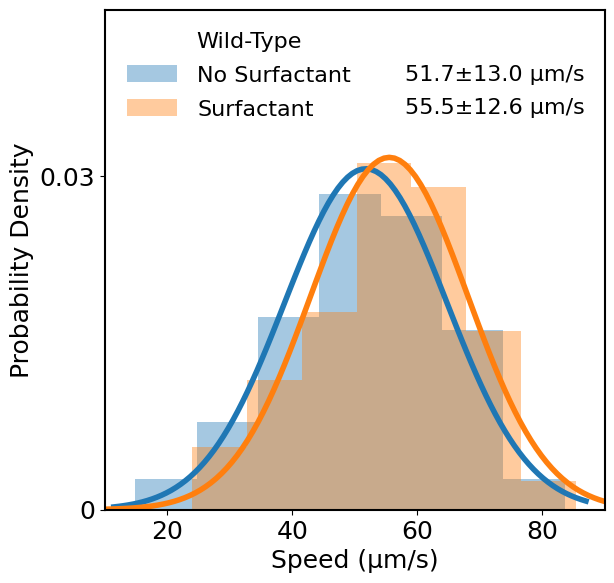

In [7]:
color_large = '#FF7F0E'  # orange
color_small = '#1F77B4'  # blue

# for other comparison
# color_gray_light = '#C4C4C4'
# color_gray_dark = '#7A7A7A'

# color_large = color_gray_dark
# color_small = color_gray_light

from scipy import stats

# not combine, calculate Fraction backward for each pair
data_current = no_F108_combined_speed.copy()
# prepare data
# limit N 
N_limit = 258
np.random.seed(1)
data_current = data_current.sample(n=N_limit, random_state=1)
# plot Track median speed as hist
plt.figure(figsize=(5, 5))
plt.hist(data_current['Track median speed'], bins=7, color=color_small, alpha=0.4, density=True, label='No Surfactant')
# add Gaussian fit
mu, std = stats.norm.fit(data_current['Track median speed'].dropna())
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mu, std)
plt.plot(x, p, color_small, linewidth=4)
print('N=', len(data_current['Track median speed'].dropna()))
print('mean=', data_current['Track median speed'].mean().round(2), 'std=', data_current['Track median speed'].std().round(2), 'median=', data_current['Track median speed'].median().round(2))

# add text about mean and std
plt.text(58, 0.0386, '%.1f' % data_current['Track median speed'].mean().round(2)+'±%.1f' % data_current['Track median speed'].std().round(2)+' µm/s', fontsize=18, color='k')

data_current = F108_combined_speed.copy()
# limit N 
N_limit = 265
np.random.seed(9)
data_current = data_current.sample(n=N_limit, random_state=1)
# prepare data
plt.hist(data_current['Track median speed'], bins=7, color=color_large, alpha=0.4, density=True, label='Surfactant')
# add Gaussian ctant', color=color_large,fit
mu, std = stats.norm.fit(data_current['Track median speed'].dropna())
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mu, std)
plt.plot(x, p, color_large, linewidth=4)
print('N=', len(data_current['Track median speed'].dropna()))
print('mean=', data_current['Track median speed'].mean().round(2), 'std=', data_current['Track median speed'].std().round(2), 'median=', data_current['Track median speed'].median().round(2))

# add text about mean and std
plt.text(58, 0.0356, '%.1f' % data_current['Track median speed'].mean().round(2)+'±%.1f' % data_current['Track median speed'].std().round(2)+' µm/s', fontsize=18, color='k')


# # add legend
# plt.legend(loc='upper left', fontsize=18, frameon=False, title='Wild-Type', title_fontsize=16)
# legend = plt.gca().get_legend() 
# legend.get_title().set_position((8, 0))  # (x, y) offset
# # # shift legend
# # legend.set_bbox_to_anchor((1.02, 1))  # (x, y) position of the legend box

plt.legend(loc='upper left', fontsize=18, frameon=False, title='Wild-Typey', title_fontsize='16')
# hide title
legend = plt.gca().get_legend()
legend.get_title().set_color('white')
# add title
plt.text(0.2875, 0.936, 'Wild-Type', fontsize=18, ha='center', va='center', transform=plt.gca().transAxes, zorder=10, color='k')


# label
plt.xlabel('Speed (µm/s)', fontsize=18)
plt.ylabel('Probability Density', fontsize=18)

# x lim
plt.xlim(10, 90)
plt.ylim(0, 0.045)

# # --- dashed line of other bias---
# # open field bias: 0.25
# # outside bias: 0.33
# plt.axvline(x=0.25, color='black', linestyle='--', linewidth=1.5)
# plt.axvline(x=0.33, color='black', linestyle='--', linewidth=1.5)

# plt.figure(figsize=(6,5.5))

# ---Parameters---
ax = plt.gca()
# Font sizes
ax.tick_params(axis='both', which='major', labelsize=18)  # Tick label size

# Get the current content of the labels and title
xlabel = ax.get_xlabel()
ylabel = ax.get_ylabel()
title = ax.get_title()

# Set the font sizes without changing the content
ax.set_xlabel(xlabel, fontsize=18)  # X-axis label size
ax.set_ylabel(ylabel, fontsize=18)  # Y-axis label size
ax.set_title(title, fontsize=18)  # Title size

# Set legend size (if you have a legend)
legend = ax.get_legend()
if legend:
    for label in legend.get_texts():
        label.set_fontsize(16)

# Set text size for any additional annotations
for text in ax.texts:
    text.set_fontsize(16)

# Make axes thicker
for spine in ['top', 'right', 'bottom', 'left']:
    ax.spines[spine].set_linewidth(1.5)

# Reduce num of ticks
# ax.locator_params(axis='y', nbins=6)
# ax.locator_params(axis='x', nbins=4)
# set x ticks
plt.xticks([20, 40, 60, 80], ['20', '40', '60', '80'], fontsize=18)
# set y ticks
plt.yticks([0, 0.03], ['0', '0.03'], fontsize=18)

# ---set box size---
def set_size(w,h, ax=None):
    """ w, h: width, height in inches """
    if not ax: ax=plt.gca()
    l = ax.figure.subplotpars.left
    r = ax.figure.subplotpars.right
    t = ax.figure.subplotpars.top
    b = ax.figure.subplotpars.bottom
    figw = float(w)/(r-l)
    figh = float(h)/(t-b)
    ax.figure.set_size_inches(figw, figh)

set_size(5, 5)

## Save figure as PNG (optional), transparent background, tight bounding box
# plt.savefig('F108_speed_WT.png', format='png', dpi=900, transparent=True)
# plt.savefig('F108_speed_WT.png', format='png', dpi=900, transparent=True, bbox_inches='tight')


N= 249
mean= 43.17 std= 12.75 median= 43.39
N= 262
mean= 37.37 std= 10.93 median= 37.34


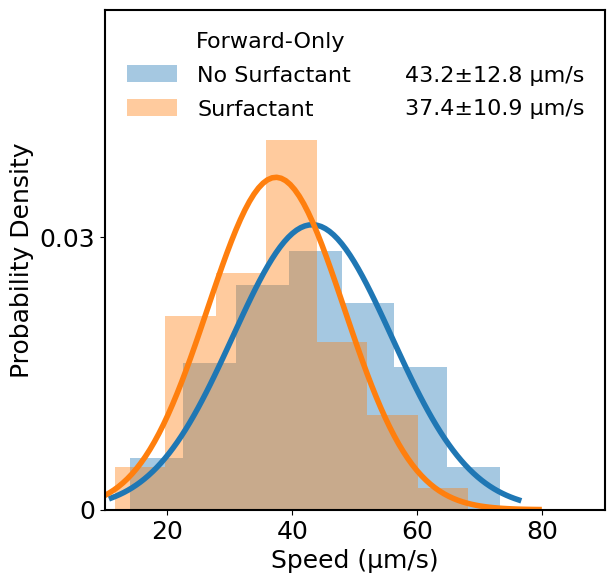

In [8]:
color_large = '#FF7F0E'  # orange
color_small = '#1F77B4'  # blue

from scipy import stats

# not combine, calculate Fraction backward for each pair
data_current = FO_no_F108_combined_speed.copy()
# prepare data
# plot Track median speed as hist
plt.figure(figsize=(5, 5))
plt.hist(data_current['Track median speed'], bins=7, color=color_small, alpha=0.4, density=True, label='No Surfactant')
# add Gaussian fit
mu, std = stats.norm.fit(data_current['Track median speed'].dropna())
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mu, std)
plt.plot(x, p, color_small, linewidth=4)
print('N=', len(data_current['Track median speed'].dropna()))
print('mean=', data_current['Track median speed'].mean().round(2), 'std=', data_current['Track median speed'].std().round(2), 'median=', data_current['Track median speed'].median().round(2))
# add text about mean and std
plt.text(58, 0.0471, '%.1f' % data_current['Track median speed'].mean().round(2)+'±%.1f' % data_current['Track median speed'].std().round(2)+' µm/s', fontsize=18, color='k')


data_current = FO_F108_combined_speed.copy()
# limit N 
N_limit = 262
np.random.seed(1)
data_current = data_current.sample(n=N_limit, random_state=1)
# prepare data
plt.hist(data_current['Track median speed'], bins=7, color=color_large, alpha=0.4, density=True, label='Surfactant')
# add Gaussian fit
mu, std = stats.norm.fit(data_current['Track median speed'].dropna())
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mu, std)
plt.plot(x, p, color_large, linewidth=4)
print('N=', len(data_current['Track median speed'].dropna()))
print('mean=', data_current['Track median speed'].mean().round(2), 'std=', data_current['Track median speed'].std().round(2), 'median=', data_current['Track median speed'].median().round(2))
# add text about mean and std
plt.text(58, 0.0435, '%.1f' % data_current['Track median speed'].mean().round(2)+'±%.1f' % data_current['Track median speed'].std().round(2)+' µm/s', fontsize=18, color='k')

# add legend
plt.legend(loc='upper right', fontsize=18, frameon=False, title='Forward-Only', title_fontsize='16')
# legend = plt.gca().get_legend()
# legend.get_title().set_position((0, 0))  # (x, y) offset
# # shift legend
# legend.set_bbox_to_anchor((1.02, 1))  # (x, y) position of the legend box

plt.legend(loc='upper left', fontsize=18, frameon=False, title='Forward-Only', title_fontsize='16')
# hide title
legend = plt.gca().get_legend()
legend.get_title().set_color('white')
# add title
plt.text(0.332, 0.936, 'Forward-Only', fontsize=18, ha='center', va='center', transform=plt.gca().transAxes, zorder=10, color='k')

# label
plt.xlabel('Speed (µm/s)', fontsize=16)
plt.ylabel('Probability Density', fontsize=16)

# x lim
plt.xlim(10, 90)
# plt.ylim(0, 0.045)
plt.ylim(0, 0.055)

# # --- dashed line of other bias---
# # open field bias: 0.25
# # outside bias: 0.33
# plt.axvline(x=0.25, color='black', linestyle='--', linewidth=1.5)
# plt.axvline(x=0.33, color='black', linestyle='--', linewidth=1.5)

# plt.figure(figsize=(6,5.5))

# plt.figure(figsize=(6,5.5))

# ---Parameters---
ax = plt.gca()
# Font sizes
ax.tick_params(axis='both', which='major', labelsize=18)  # Tick label size

# Get the current content of the labels and title
xlabel = ax.get_xlabel()
ylabel = ax.get_ylabel()
title = ax.get_title()

# Set the font sizes without changing the content
ax.set_xlabel(xlabel, fontsize=18)  # X-axis label size
ax.set_ylabel(ylabel, fontsize=18)  # Y-axis label size
ax.set_title(title, fontsize=18)  # Title size

# Set legend size (if you have a legend)
legend = ax.get_legend()
if legend:
    for label in legend.get_texts():
        label.set_fontsize(16)

# Set text size for any additional annotations
for text in ax.texts:
    text.set_fontsize(16)

# Make axes thicker
for spine in ['top', 'right', 'bottom', 'left']:
    ax.spines[spine].set_linewidth(1.5)

# Reduce num of ticks
# ax.locator_params(axis='y', nbins=6)
# ax.locator_params(axis='x', nbins=6)
# set x ticks
plt.xticks([20, 40, 60, 80], ['20', '40', '60', '80'], fontsize=18)
# set y ticks
plt.yticks([0, 0.03], ['0', '0.03'], fontsize=18)


# ---set box size---
def set_size(w,h, ax=None):
    """ w, h: width, height in inches """
    if not ax: ax=plt.gca()
    l = ax.figure.subplotpars.left
    r = ax.figure.subplotpars.right
    t = ax.figure.subplotpars.top
    b = ax.figure.subplotpars.bottom
    figw = float(w)/(r-l)
    figh = float(h)/(t-b)
    ax.figure.set_size_inches(figw, figh)

set_size(5, 5)

## Save figure as PNG (optional), transparent background, not tight bounding box
# plt.savefig('F108_speed_FO.png', format='png', dpi=900, transparent=True)
# plt.savefig('F108_speed_FO.png', format='png', dpi=900, transparent=True, bbox_inches='tight')
